In [2]:
import pandas as pd


In [3]:
df = pd.read_csv("../data/listings.csv")

In [ ]:
print(df.shape)
print(df.head())

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22708 entries, 0 to 22707
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            22708 non-null  int64  
 1   listing_url                                   22708 non-null  str    
 2   scrape_id                                     22708 non-null  int64  
 3   last_scraped                                  22708 non-null  str    
 4   source                                        22708 non-null  str    
 5   name                                          22708 non-null  str    
 6   description                                   21823 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   22707 non-null  str    
 9   host_id                                       22708 non-null  int64  
 1

In [13]:
df[["price", "price_quote_price_per_night"]].head(10)

,price,price_quote_price_per_night
0,$42.00,42.00
1,$209.98,209.98
2,NaN,NaN
3,NaN,NaN
4,$259.09,259.09
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


In [18]:
df["price_num"] = df["price"].str.replace("$", "").str.replace(",", "").astype(float)

In [23]:
df["price_num"].equals(df["price_quote_price_per_night"])

True

price_num and price_quote_price_per_night columns are equal.

In [24]:
df["price_num"].describe()

count    19172.000000
mean       180.056266
std        555.620344
min          3.360000
25%         83.745000
50%        125.000000
75%        184.000000
max      36883.000000
Name: price_num, dtype: float64

count_low: 146, pct_low: 0.76%
count_high: 165, pct_high: 0.86%


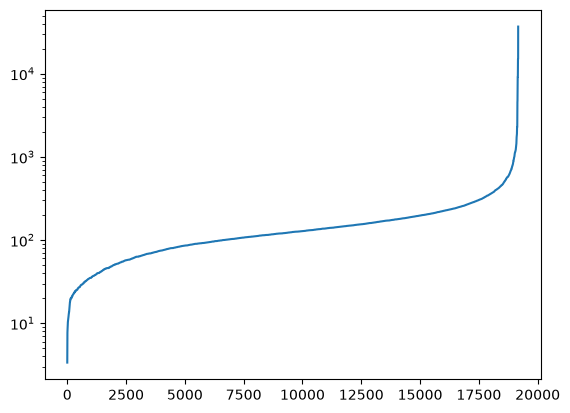

In [40]:
df["price_num"].dropna().sort_values().reset_index(drop=True).plot(logy=True)
count_low = (df["price_num"] < 20).sum()
count_high = (df["price_num"] > 1000).sum()
pct_low = 100 * count_low / df["price"].count()
pct_high = 100 * count_high / df["price"].count()
print(f"count_low: {count_low}, pct_low: {round(pct_low, 2)}%")
print(f"count_high: {count_high}, pct_high: {round(pct_high, 2)}%")

## Q1: What is the price distribution? How frequent are extreme values?

The sorted price plot (log scale, cell above) shows a distribution skewed to the right: most listings sit in a moderate range, and a small tail of very expensive listings rises quickly at the end. That tail pulls the mean up to [mean] €, above the median of [median] €, so the median describes a typical listing better than the mean.

Extreme values, over the 19,172 listings with a price:

| range       | listings | % of priced listings |
|-------------|---------:|---------------------:|
| below 20 €  |      146 |               0.76 % |
| above 1,000 € |    165 |               0.86 % |

Each group is under 1 %, and 1.6 % together. Extremes are rare, but large enough to distort the mean.

In [46]:
NaN_prices = df["price"].isna().sum()
pct_NaN_prices = NaN_prices / len(df) * 100
print(f"NaN_prices: {NaN_prices}")
print(f"pct_NaN_prices: {round(pct_NaN_prices, 2)}%")

df["price_missing"] = df["price_num"].isna()
print(df.groupby("source")["price_missing"].size())
print(df.groupby("source")["price_missing"].mean())

NaN_prices: 3536
pct_NaN_prices: 15.57%
source
city scrape        18548
previous scrape     4160
Name: price_missing, dtype: int64
source
city scrape        0.015366
previous scrape    0.781490
Name: price_missing, dtype: float64


## Q2: How many prices are missing? Where do they come from?

3,536 of the 22,708 listings (15.57 %) have no price.

| source          | listings | missing price | % missing |
|-----------------|---------:|--------------:|----------:|
| city scrape     |   18,548 |           285 |     1.5 % |
| previous scrape |    4,160 |         3,251 |    78.1 % |

The missing prices are not random: 92 % of them (3,251 of 3,536) come from listings marked as "previous scrape", which were seen in an earlier scrape but not found in this one. These are most likely listings that are no longer active, so they have no current price. Candidate decision for T2 (cleaning): drop the "previous scrape" listings and justify it with these numbers.

In [74]:
print(df["neighbourhood_cleansed"].nunique())
print(df["neighbourhood_group_cleansed"].nunique())

128
21


In [ ]:
counts = df.groupby("neighbourhood_cleansed")["price_num"].count().sort_values()
medians = df.groupby("neighbourhood_cleansed")["price_num"].median().sort_values()

print(counts.head())
print(counts.tail())
print((counts < 20).sum())
print(counts[counts < 20].sum())
print(medians[counts >= 20].head())
print(medians[counts >= 20].tail())
print(round(medians[counts >= 20].median(), 2))

neighbourhood_cleansed
Atalaya          0
El Pardo         2
Horcajo          2
Fuentelareina    5
El Goloso        5
Name: price_num, dtype: int64
neighbourhood_cleansed
Justicia        943
Sol            1125
Palacio        1469
Universidad    1658
Embajadores    2048
Name: price_num, dtype: int64
23
230
neighbourhood_cleansed
Apostol Santiago    48.500
Campamento          50.500
Aguilas             52.850
Portazgo            55.000
Entrevías           62.665
Name: price_num, dtype: float64
neighbourhood_cleansed
Sol           163.880
Castellana    164.630
Goya          168.665
Jerónimos     170.040
Recoletos     193.685
Name: price_num, dtype: float64
109.55


## Q3: How does the price change across neighbourhoods?

There are two clean location columns: `neighbourhood_cleansed` (128 neighbourhoods) and `neighbourhood_group_cleansed` (21 districts). This answer uses neighbourhoods, since nearby areas can have very different prices. Neighbourhoods with fewer than 20 priced listings are excluded, because their median would rely on just a few listings: this removes 23 neighbourhoods and 230 listings (1.2 % of the 19,172 priced listings). Prices are compared with the median, because of the long tail seen in Q1.

| cheapest         | median price | most expensive | median price |
|------------------|-------------:|----------------|-------------:|
| Apostol Santiago |      48.50 € | Recoletos      |     193.69 € |
| Campamento       |      50.50 € | Jerónimos      |     170.04 € |
| Aguilas          |      52.85 € | Goya           |     168.67 € |
| Portazgo         |      55.00 € | Castellana     |     164.63 € |
| Entrevías        |      62.67 € | Sol            |     163.88 € |

The median price in Recoletos is 4 times the one in Apostol Santiago. The most expensive neighbourhoods are in the centre and the Salamanca area; the cheapest are on the outskirts. The neighbourhood is strongly associated with the price, but this does not prove it is the cause: other factors, such as the type of listing, may differ between neighbourhoods.

The median listing costs 125.00 €, but the median of the neighbourhood medians is 109.55 €. The gap appears because expensive neighbourhoods also have many listings: the five largest, all in the centre, hold almost 38 % of the priced listings and pull the overall median up.

In [65]:
print(df["room_type"].nunique())

4


In [90]:
counts_rooms = df.groupby("room_type")["price_num"].count().sort_values()
medians_rooms = df.groupby("room_type")["price_num"].median().sort_values()
df["is_home_apt"] = df["room_type"] == "Entire home/apt"
priced = df[df["price_num"].notna()]
entire_share = priced.groupby("neighbourhood_cleansed")["is_home_apt"].mean().sort_values()
print(len(priced))

medians_q3 = medians[counts >= 20].sort_values()
cheap = medians_q3.head(5).index
expensive = medians_q3.tail(5).index

print(counts_rooms)
print(medians_rooms)
print(entire_share[cheap])
print(entire_share[expensive])


19172
room_type
Hotel room            29
Shared room          142
Private room        5065
Entire home/apt    13936
Name: price_num, dtype: int64
room_type
Shared room         25.0
Private room        64.0
Hotel room         104.0
Entire home/apt    144.0
Name: price_num, dtype: float64
neighbourhood_cleansed
Apostol Santiago    0.233333
Campamento          0.200000
Aguilas             0.150000
Portazgo            0.351351
Entrevías           0.407407
Name: is_home_apt, dtype: float64
neighbourhood_cleansed
Sol           0.751111
Castellana    0.897959
Goya          0.874150
Jerónimos     0.765432
Recoletos     0.890152
Name: is_home_apt, dtype: float64


## Q4: How much does the room type affect the price?

| Room type | Priced listings | Median (€) |
|---|---:|---:|
| Entire home/apt | 13.936 | 144 |
| Private room | 5.065 | 64 |
| Hotel room | 29 | 104 |
| Shared room | 142 | 25 |

*Hotel room only has 29 listings: its median is unreliable*

Among the 5 cheapest and 5 most expensive neighbourhoods from Q3, Entire home/apt listings made up just 15–41% of the cheapest neighbourhoods but 75–90% of the most expensive. As Entire home/apt listings are 72% of the total listings, expensive neighbourhoods sit right above while the cheapest are significantly below. Since apartments are the priciest room type, this higher concentration may partly explain why these areas are so expensive.

In [105]:
counts_acc = priced.groupby("accommodates").size()
medians_acc = priced.groupby("accommodates")["price_num"].median()
priced["price_per_guest"] = priced["price_num"] / priced["accommodates"]
medians_ppeg = priced.groupby("accommodates")["price_per_guest"].median()
print(counts_acc)
print(medians_acc[counts_acc >= 20])
print(medians_ppeg[counts_acc >= 20])

accommodates
1     2236
2     6540
3     1909
4     5036
5      835
6     1674
7      211
8      413
9       67
10     112
11       8
12      55
13       8
14      19
15      11
16      38
dtype: int64
accommodates
1      44.00
2     100.66
3     125.00
4     148.00
5     175.60
6     213.50
7     230.70
8     294.60
9     367.00
10    467.00
12    549.00
16    515.25
Name: price_num, dtype: float64
accommodates
1     44.000000
2     50.330000
3     41.666667
4     37.000000
5     35.120000
6     35.583333
7     32.957143
8     36.825000
9     40.777778
10    46.700000
12    45.750000
16    32.203125
Name: price_per_guest, dtype: float64


## Q5: How does the number of guests affect the price?

| Guests | Priced listings | Median (€) | Median per guest (€) |
|---:|---:|---:|---:|
| 1 | 2,236 | 44.00 | 44.00 |
| 2 | 6,540 | 100.66 | 50.33 |
| 3 | 1,909 | 125.00 | 41.67 |
| 4 | 5,036 | 148.00 | 37.00 |
| 5 | 835 | 175.60 | 35.12 |
| 6 | 1,674 | 213.50 | 35.58 |
| 7 | 211 | 230.70 | 32.96 |
| 8 | 413 | 294.60 | 36.83 |
| 9 | 67 | 367.00 | 40.78 |
| 10 | 112 | 467.00 | 46.70 |
| 12 | 55 | 549.00 | 45.75 |
| 16 | 38 | 515.25 | 32.20 |

*Groups with fewer than 20 priced listings (11, 13, 14 and 15 guests; 46 listings, 0.24%) are excluded. Groups from 9 guests upwards are small, so their medians are less reliable.*

The table shows that prices increase with the number of guests, but not proportionately. Listings that accommodate 2 guests have the highest price at 50€ per guest, while groups of 4 to 8 cost around 32€ to 37€. This may be because while room space scales roughly proportional to the number of guests, amenities such as kitchens and bathrooms tend to cost less per guest as the group size increases. Looking back at Q3 and Q4, it may also be that apartments in the center tend to be for 2 guests, making these listings pricier on average.

In [29]:
clean = pd.read_csv("../data/listings_clean.csv")
clean.info()
print(clean["amenities"].head())
print(clean["bathrooms_text"].head())
clean.groupby("bathrooms_text")["price"].mean()

<class 'pandas.DataFrame'>
RangeIndex: 18211 entries, 0 to 18210
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            18211 non-null  int64  
 1   listing_url                                   18211 non-null  str    
 2   scrape_id                                     18211 non-null  int64  
 3   last_scraped                                  18211 non-null  str    
 4   source                                        18211 non-null  str    
 5   name                                          18211 non-null  str    
 6   description                                   17698 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   18211 non-null  str    
 9   host_id                                       18211 non-null  int64  
 1

bathrooms_text
0 baths               156.042902
0 shared baths         58.514806
1 bath                148.703301
1 private bath        129.578785
1 shared bath          77.524056
1.5 baths             177.699075
1.5 shared baths       86.835000
10 baths               65.000000
10 shared baths        44.400000
19 baths               59.000000
2 baths               241.130352
2 shared baths         68.712743
2.5 baths             335.490000
2.5 shared baths       93.784286
3 baths               345.103550
3 shared baths         51.272703
3.5 baths             505.205254
3.5 shared baths       60.335000
38 baths              122.000000
4 baths               553.579277
4 shared baths         69.877273
4.5 baths             554.962353
4.5 shared baths       52.000000
5 baths               529.733125
5 shared baths         59.450667
5.5 baths             684.908333
6 baths               708.813636
6 shared baths         37.000000
6.5 baths             647.300000
7 baths               692.00

In [20]:
clean["host_is_superhost"].dtype

dtype('bool')

In [27]:
cols = ["review_scores_rating", "hosts_time_as_host_months", "bedrooms", "beds", "accommodates", "amenities", "latitude", "longitude", "property_type", "room_type", "bathrooms", "neighbourhood_cleansed", "minimum_nights", "maximum_nights", "host_is_superhost", "bathrooms_text"]

for col in cols:
    print(col + "_sum: " + f"{clean[col].isna().sum()}")
    print(col + "_mean: " + f"{round(100 * clean[col].isna().mean(), 2)}%")

review_scores_rating_sum: 2441
review_scores_rating_mean: 13.4%
hosts_time_as_host_months_sum: 0
hosts_time_as_host_months_mean: 0.0%
bedrooms_sum: 3930
bedrooms_mean: 21.58%
beds_sum: 374
beds_mean: 2.05%
accommodates_sum: 0
accommodates_mean: 0.0%
amenities_sum: 0
amenities_mean: 0.0%
latitude_sum: 0
latitude_mean: 0.0%
longitude_sum: 0
longitude_mean: 0.0%
property_type_sum: 0
property_type_mean: 0.0%
room_type_sum: 0
room_type_mean: 0.0%
bathrooms_sum: 1232
bathrooms_mean: 6.77%
neighbourhood_cleansed_sum: 0
neighbourhood_cleansed_mean: 0.0%
minimum_nights_sum: 0
minimum_nights_mean: 0.0%
maximum_nights_sum: 0
maximum_nights_mean: 0.0%
host_is_superhost_sum: 0
host_is_superhost_mean: 0.0%
bathrooms_text_sum: 15
bathrooms_text_mean: 0.08%


In [28]:
clean["first_review"].isna().sum()

np.int64(2441)

In [33]:
print(clean[["estimated_revenue_l365d", "estimated_occupancy_l365d", "price"]].head(10))


   estimated_revenue_l365d  estimated_occupancy_l365d    price
0                      0.0                          0    42.00
1                      0.0                          0   209.98
2                      0.0                          0    95.00
3                  39234.0                         78   503.00
4                      0.0                          0   149.68
5                      0.0                          0    88.00
6                  30876.0                        186   166.00
7                   6680.0                         30   222.67
8                      0.0                          0  1141.00
9                   1344.0                         12   112.00


In [7]:
train = pd.read_csv("../data/train.csv")
train["missing_bedrooms"] = train["bedrooms"].isna()
print(train.groupby("accommodates")["beds"].median())

accommodates
1      1.0
2      1.0
3      2.0
4      2.0
5      3.0
6      3.0
7      4.0
8      5.0
9      6.0
10     6.0
11     7.0
12     7.0
13     9.0
14     8.0
15    10.0
16    12.5
Name: beds, dtype: float64


In [8]:
train["bathrooms_text"].value_counts()

bathrooms_text
1 bath               6891
2 baths              1870
1 shared bath        1188
1 private bath        988
1.5 baths             291
2 shared baths        286
3 baths               253
0 baths               176
0 shared baths        153
1.5 shared baths      135
2.5 baths              93
Shared half-bath       83
4 baths                55
3 shared baths         53
3.5 baths              40
Half-bath              36
Private half-bath      25
5 baths                24
5 shared baths         23
4 shared baths         17
2.5 shared baths       12
4.5 baths              10
10 shared baths         8
8 shared baths          6
6 baths                 6
5.5 baths               5
8 baths                 2
7 baths                 2
7 shared baths          2
6.5 baths               1
19 baths                1
4.5 shared baths        1
3.5 shared baths        1
38 baths                1
Name: count, dtype: int64

In [ ]:
train["bath_num"] = train["bathrooms_text"].str.lower().str.replace("half-bath", "0.5 baths").str.replace("shared ", "").str.replace("private ", "").str.split(" ").str[0].astype(float)

train["bath_num"].value_counts()

mask = train["bath_num"].notna() & train["bathrooms"].notna()
(train["bath_num"][mask] != train["bathrooms"][mask]).sum()

train["bath_shared"] = train["bathrooms_text"].str.lower().str.contains("shared")